In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from helpers import load_result, moving_average

In [2]:
# Global constants
WINDOW_SIZE = 500
# Save the plot
IMAGES_DIR = '../images'
DATASET_NAME = 'msmarco'
os.makedirs(IMAGES_DIR, exist_ok=True)

In [3]:
eps_greedy_e01_lambda05_path = "../results/EpsilonGreedy_e=0.1_lambda=0.5_metric=recall_seed=42_dataset=ms_marco.json"
ucb_c2_lambda05_path = "../results/UCB_c=2.0_lambda=0.5_metric=recall_seed=42_dataset=ms_marco.json"
thompson_lambda05_path = "../results/ThompsonSampling_lambda=0.5_metric=recall_seed=42_dataset=ms_marco.json"

eps_greedy_e01_lambda05_results = load_result(eps_greedy_e01_lambda05_path)
ucb_c2_lambda05_results = load_result(ucb_c2_lambda05_path)
thompson_lambda05_results = load_result(thompson_lambda05_path)

In [4]:
# Check the fields in the results
print(eps_greedy_e01_lambda05_results.keys())
print(ucb_c2_lambda05_results.keys())
print(thompson_lambda05_results.keys())

dict_keys(['run_name', 'bandit', 'params', 'lambda_param', 'total_queries', 'avg_score', 'avg_latency', 'policy_proportions', 'rewards', 'scores', 'latencies', 'selected_arms', 'arm_map'])
dict_keys(['run_name', 'bandit', 'params', 'lambda_param', 'total_queries', 'avg_score', 'avg_latency', 'policy_proportions', 'rewards', 'scores', 'latencies', 'selected_arms', 'arm_map'])
dict_keys(['run_name', 'bandit', 'params', 'lambda_param', 'total_queries', 'avg_score', 'avg_latency', 'policy_proportions', 'rewards', 'scores', 'latencies', 'selected_arms', 'arm_map'])


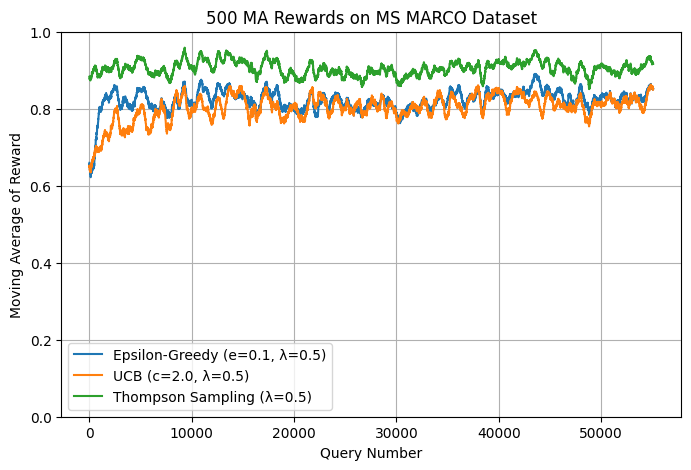

In [5]:
# Compute the moving averages of the rewards
eps_greedy_e01_lambda05_ma = moving_average(eps_greedy_e01_lambda05_results['rewards'], WINDOW_SIZE, mode='valid')
ucb_c2_lambda05_ma = moving_average(ucb_c2_lambda05_results['rewards'], WINDOW_SIZE, mode='valid')
thompson_lambda05_ma = moving_average(thompson_lambda05_results['rewards'], WINDOW_SIZE, mode='valid')

# Plot the moving averages
plt.figure(figsize=(8, 5))
plt.plot(eps_greedy_e01_lambda05_ma, label='Epsilon-Greedy (e=0.1, λ=0.5)')
plt.plot(ucb_c2_lambda05_ma, label='UCB (c=2.0, λ=0.5)')
plt.plot(thompson_lambda05_ma, label='Thompson Sampling (λ=0.5)')
plt.title(f'{WINDOW_SIZE} MA Rewards on MS MARCO Dataset')
plt.xlabel('Query Number')
plt.ylabel('Moving Average of Reward')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

# Save the plot
plt.savefig(
    os.path.join(IMAGES_DIR, f'{DATASET_NAME}_mab_base_config_{WINDOW_SIZE}_ma_rewards.png'),
    bbox_inches='tight',
    dpi=300
)

# Show the plot
plt.show()

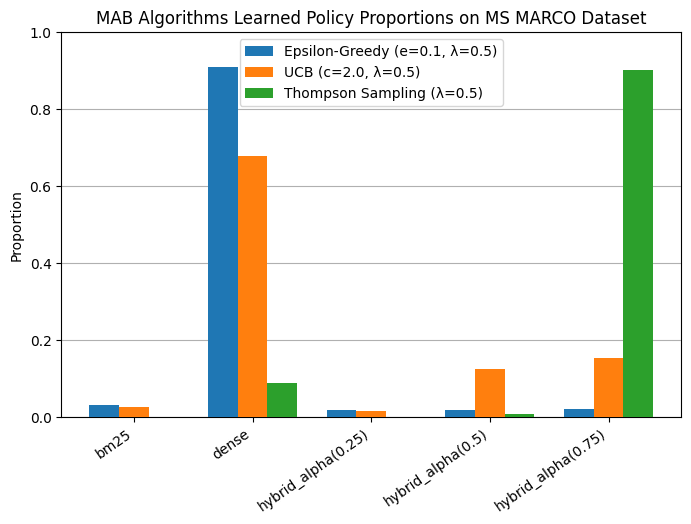

In [6]:
# Plot the policy proportions
eps_greedy_e01_lambda05_prop = eps_greedy_e01_lambda05_results['policy_proportions']
ucb_c2_lambda05_prop = ucb_c2_lambda05_results['policy_proportions']
thompson_lambda05_prop = thompson_lambda05_results['policy_proportions']

# Plot the proportions on a grouped bar chart
policies = list(eps_greedy_e01_lambda05_prop.keys())
x = np.arange(len(policies))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, eps_greedy_e01_lambda05_prop.values(), width, label='Epsilon-Greedy (e=0.1, λ=0.5)', zorder=3)
plt.bar(x, ucb_c2_lambda05_prop.values(), width, label='UCB (c=2.0, λ=0.5)', zorder=3)
plt.bar(x + width, thompson_lambda05_prop.values(), width, label='Thompson Sampling (λ=0.5)', zorder=3)
plt.xticks(x, policies, rotation=35, ha='right')
plt.ylabel('Proportion')
plt.title('MAB Algorithms Learned Policy Proportions on MS MARCO Dataset')
plt.ylim(0, 1)
plt.grid(axis='y', zorder=0)
plt.legend()

# Save the plot
plt.savefig(
    os.path.join(IMAGES_DIR, f'{DATASET_NAME}_mab_base_config_policy_proportions.png'),
    bbox_inches='tight',
    dpi=300
)

# Show the plot
plt.show()

In [7]:
eps_greedy_e001_lambda05_path = "../results/EpsilonGreedy_e=0.01_lambda=0.5_metric=recall_seed=42_dataset=ms_marco.json"
eps_greedy_e03_lambda05_path = "../results/EpsilonGreedy_e=0.3_lambda=0.5_metric=recall_seed=42_dataset=ms_marco.json"

eps_greedy_e001_lambda05_results = load_result(eps_greedy_e001_lambda05_path)
eps_greedy_e03_lambda05_results = load_result(eps_greedy_e03_lambda05_path)

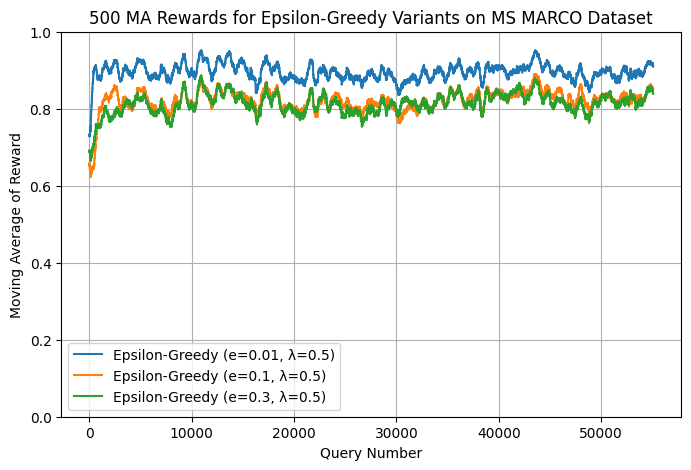

In [8]:
# Calculate moving averages
eps_greedy_e001_lambda05_ma = moving_average(eps_greedy_e001_lambda05_results['rewards'], WINDOW_SIZE, mode='valid')
eps_greedy_e03_lambda05_ma = moving_average(eps_greedy_e03_lambda05_results['rewards'], WINDOW_SIZE, mode='valid')

# Plot the moving averages for different epsilon values
plt.figure(figsize=(8, 5))
plt.plot(eps_greedy_e001_lambda05_ma, label='Epsilon-Greedy (e=0.01, λ=0.5)')
plt.plot(eps_greedy_e01_lambda05_ma, label='Epsilon-Greedy (e=0.1, λ=0.5)')
plt.plot(eps_greedy_e03_lambda05_ma, label='Epsilon-Greedy (e=0.3, λ=0.5)')
plt.title(f'{WINDOW_SIZE} MA Rewards for Epsilon-Greedy Variants on MS MARCO Dataset')
plt.xlabel('Query Number')
plt.ylabel('Moving Average of Reward')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

# Save the plot
plt.savefig(
    os.path.join(IMAGES_DIR, f'{DATASET_NAME}_eps_greedy_different_e_{WINDOW_SIZE}_ma_rewards.png'),
    bbox_inches='tight',
    dpi=300
)

# Show the plot
plt.show()

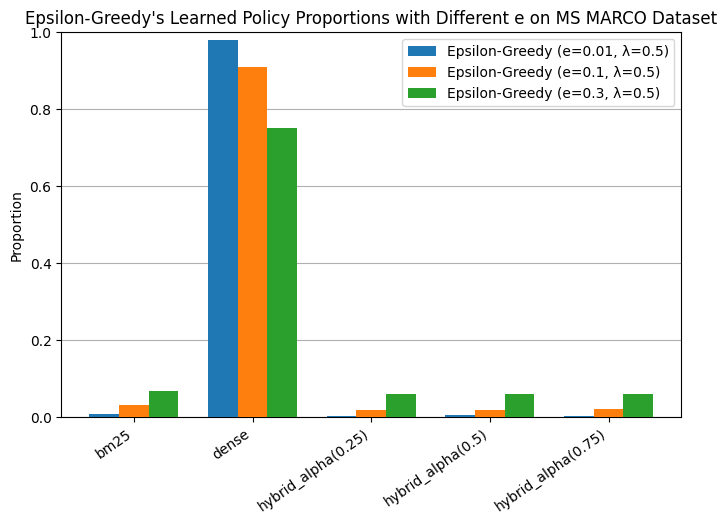

In [9]:
# Plot the policy proportions for different epsilon values
eps_greedy_e001_lambda05_prop = eps_greedy_e001_lambda05_results['policy_proportions']
eps_greedy_e03_lambda05_prop = eps_greedy_e03_lambda05_results['policy_proportions']

# Plot the proportions on a grouped bar chart
policies = list(eps_greedy_e001_lambda05_prop.keys())
x = np.arange(len(policies))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, eps_greedy_e001_lambda05_prop.values(), width, label='Epsilon-Greedy (e=0.01, λ=0.5)', zorder = 3)
plt.bar(x, eps_greedy_e01_lambda05_prop.values(), width, label='Epsilon-Greedy (e=0.1, λ=0.5)', zorder=3)
plt.bar(x + width, eps_greedy_e03_lambda05_prop.values(), width, label='Epsilon-Greedy (e=0.3, λ=0.5)', zorder=3)
plt.xticks(x, policies, rotation=35, ha='right')
plt.ylabel('Proportion')
plt.title('Epsilon-Greedy\'s Learned Policy Proportions with Different e on MS MARCO Dataset')
plt.ylim(0, 1)
plt.grid(axis='y', zorder=0)
plt.legend()

# Save the plot
plt.savefig(
    os.path.join(IMAGES_DIR, f'{DATASET_NAME}_eps_greedy_different_e_policy_proportions.png'),
    bbox_inches='tight',
    dpi=300
)

# Show the plot
plt.show()

In [10]:
ucb_c1_lambda05_path = "../results/UCB_c=1.0_lambda=0.5_metric=recall_seed=42_dataset=ms_marco.json"
ucb_c3_lambda05_path = "../results/UCB_c=3.0_lambda=0.5_metric=recall_seed=42_dataset=ms_marco.json"

ucb_c1_lambda05_results = load_result(ucb_c1_lambda05_path)
ucb_c3_lambda05_results = load_result(ucb_c3_lambda05_path)

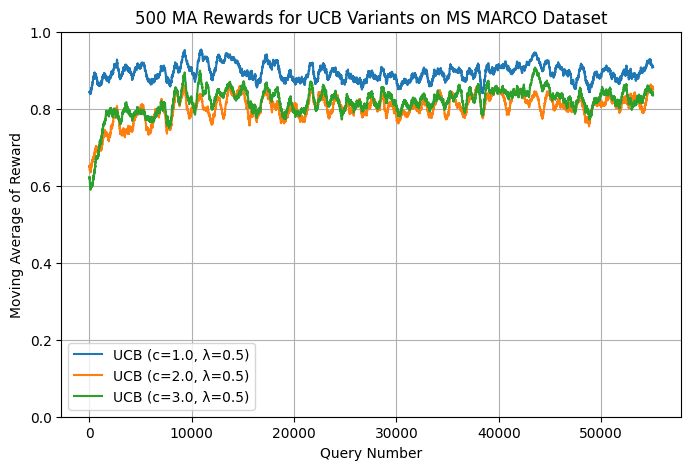

In [11]:
# Caclculate moving averages
ucb_c1_lambda05_ma = moving_average(ucb_c1_lambda05_results['rewards'], WINDOW_SIZE, mode='valid')
ucb_c3_lambda05_ma = moving_average(ucb_c3_lambda05_results['rewards'], WINDOW_SIZE, mode='valid')

# Plot the moving averages for different UCB c values
plt.figure(figsize=(8, 5))
plt.plot(ucb_c1_lambda05_ma, label='UCB (c=1.0, λ=0.5)')
plt.plot(ucb_c2_lambda05_ma, label='UCB (c=2.0, λ=0.5)')
plt.plot(ucb_c3_lambda05_ma, label='UCB (c=3.0, λ=0.5)')
plt.title(f'{WINDOW_SIZE} MA Rewards for UCB Variants on MS MARCO Dataset')
plt.xlabel('Query Number')
plt.ylabel('Moving Average of Reward')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

# Save the plot
plt.savefig(
    os.path.join(IMAGES_DIR, f'{DATASET_NAME}_ucb_different_c_{WINDOW_SIZE}_ma_rewards.png'),
    bbox_inches='tight',
    dpi=300
)

# Show the plot
plt.show()

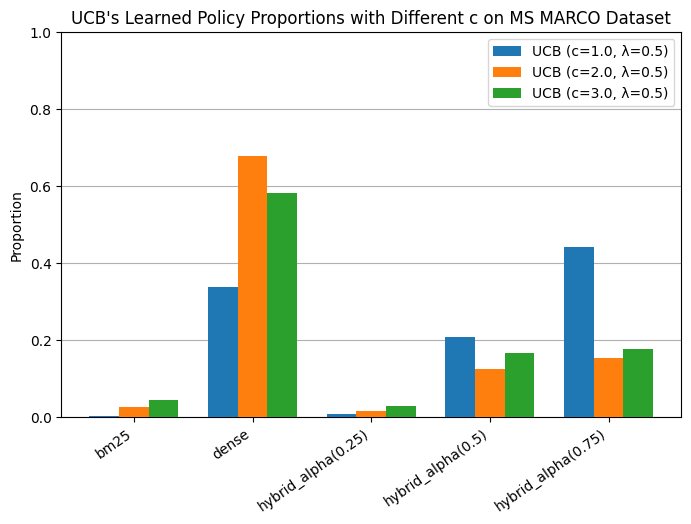

In [12]:
# Plot the policy proportions for different c values
ucb_c1_lambda05_prop = ucb_c1_lambda05_results['policy_proportions']
ucb_c3_lambda05_prop = ucb_c3_lambda05_results['policy_proportions']

# Plot the proportions on a grouped bar chart
policies = list(ucb_c1_lambda05_prop.keys())
x = np.arange(len(policies))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, ucb_c1_lambda05_prop.values(), width, label='UCB (c=1.0, λ=0.5)', zorder = 3)
plt.bar(x, ucb_c2_lambda05_prop.values(), width, label='UCB (c=2.0, λ=0.5)', zorder=3)
plt.bar(x + width, ucb_c3_lambda05_prop.values(), width, label='UCB (c=3.0, λ=0.5)', zorder=3)
plt.xticks(x, policies, rotation=35, ha='right')
plt.ylabel('Proportion')
plt.title('UCB\'s Learned Policy Proportions with Different c on MS MARCO Dataset')
plt.ylim(0, 1)
plt.grid(axis='y', zorder=0)
plt.legend()

# Save the plot
plt.savefig(
    os.path.join(IMAGES_DIR, f'{DATASET_NAME}_ucb_different_c_policy_proportions.png'),
    bbox_inches='tight',
    dpi=300
)

# Show the plot
plt.show()

In [13]:
eps_greedy_e01_lambda01_path = "../results/EpsilonGreedy_e=0.1_lambda=0.1_metric=recall_seed=42_dataset=ms_marco.json"
eps_greedy_e01_lambda09_path = "../results/EpsilonGreedy_e=0.1_lambda=0.9_metric=recall_seed=42_dataset=ms_marco.json"

eps_greedy_e01_lambda01_results = load_result(eps_greedy_e01_lambda01_path)
eps_greedy_e01_lambda09_results = load_result(eps_greedy_e01_lambda09_path)

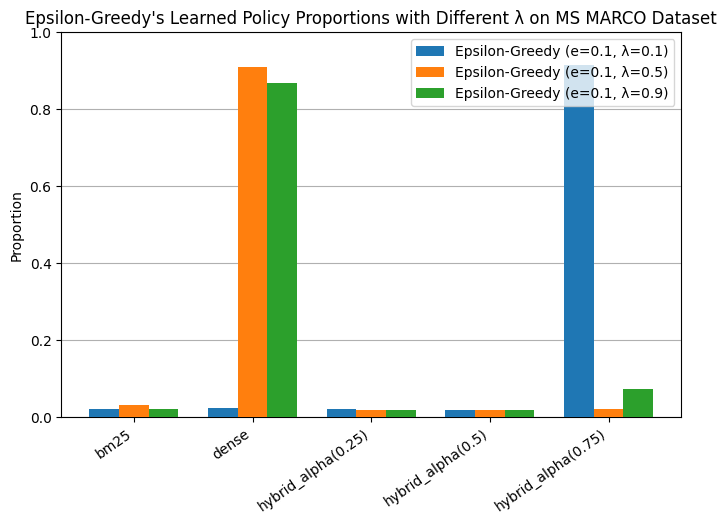

In [14]:
# Plot the learned policy proportions for different lambda values
eps_greedy_e01_lambda01_prop = eps_greedy_e01_lambda01_results['policy_proportions']
eps_greedy_e01_lambda09_prop = eps_greedy_e01_lambda09_results['policy_proportions']

# Plot the proportions on a grouped bar chart
policies = list(eps_greedy_e01_lambda01_prop.keys())
x = np.arange(len(policies))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, eps_greedy_e01_lambda01_prop.values(), width, label='Epsilon-Greedy (e=0.1, λ=0.1)', zorder = 3)
plt.bar(x, eps_greedy_e01_lambda05_prop.values(), width, label='Epsilon-Greedy (e=0.1, λ=0.5)', zorder=3)
plt.bar(x + width, eps_greedy_e01_lambda09_prop.values(), width, label='Epsilon-Greedy (e=0.1, λ=0.9)', zorder=3)
plt.xticks(x, policies, rotation=35, ha='right')
plt.ylabel('Proportion')
plt.title('Epsilon-Greedy\'s Learned Policy Proportions with Different λ on MS MARCO Dataset')
plt.ylim(0, 1)
plt.grid(axis='y', zorder=0)
plt.legend()

# Save the plot
plt.savefig(
    os.path.join(IMAGES_DIR, f'{DATASET_NAME}_eps_greedy_different_lambda_policy_proportions.png'),
    bbox_inches='tight',
    dpi=300
)

# Show the plot
plt.show()

In [15]:
ucb_c2_lambda01_path = "../results/UCB_c=2.0_lambda=0.1_metric=recall_seed=42_dataset=ms_marco.json"
ucb_c2_lambda09_path = "../results/UCB_c=2.0_lambda=0.9_metric=recall_seed=42_dataset=ms_marco.json"

ucb_c2_lambda01_results = load_result(ucb_c2_lambda01_path)
ucb_c2_lambda09_results = load_result(ucb_c2_lambda09_path)

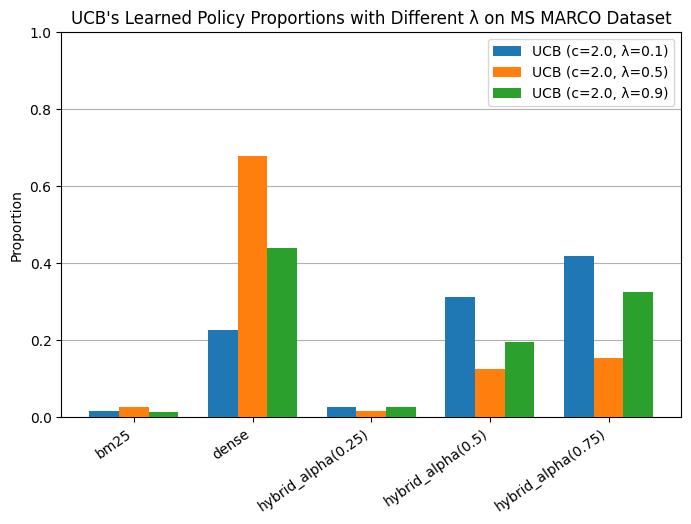

In [16]:
# Plot the learned policy proportions for different lambda values
ucb_c2_lambda01_prop = ucb_c2_lambda01_results['policy_proportions']
ucb_c2_lambda09_prop = ucb_c2_lambda09_results['policy_proportions']

# Plot the proportions on a grouped bar chart
policies = list(ucb_c2_lambda01_prop.keys())
x = np.arange(len(policies))
width = 0.25
plt.figure(figsize=(8, 5))
plt.bar(x - width, ucb_c2_lambda01_prop.values(), width, label='UCB (c=2.0, λ=0.1)', zorder = 3)
plt.bar(x, ucb_c2_lambda05_prop.values(), width, label='UCB (c=2.0, λ=0.5)', zorder=3)
plt.bar(x + width, ucb_c2_lambda09_prop.values(), width, label='UCB (c=2.0, λ=0.9)', zorder=3)
plt.xticks(x, policies, rotation=35, ha='right')
plt.ylabel('Proportion')
plt.title('UCB\'s Learned Policy Proportions with Different λ on MS MARCO Dataset')
plt.ylim(0, 1)
plt.grid(axis='y', zorder=0)
plt.legend()

# Save the plot
plt.savefig(
    os.path.join(IMAGES_DIR, f'{DATASET_NAME}_ucb_different_lambda_policy_proportions.png'),
    bbox_inches='tight',
    dpi=300
)

# Show the plot
plt.show()

In [17]:
thompson_lambda01_path = "../results/ThompsonSampling_lambda=0.1_metric=recall_seed=42_dataset=ms_marco.json"
thompson_lambda09_path = "../results/ThompsonSampling_lambda=0.9_metric=recall_seed=42_dataset=ms_marco.json"

thompson_lambda01_results = load_result(thompson_lambda01_path)
thompson_lambda09_results = load_result(thompson_lambda09_path)

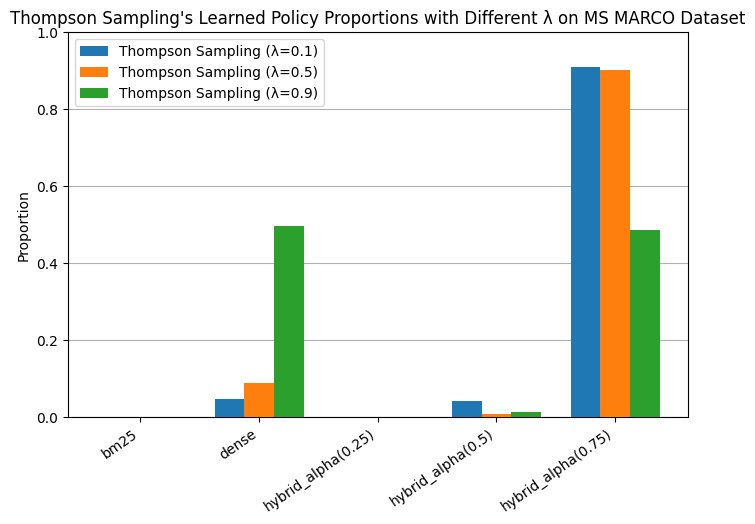

In [18]:
# Plot the learned policy proportions for different lambda values
thompson_lambda01_prop = thompson_lambda01_results['policy_proportions']
thompson_lambda09_prop = thompson_lambda09_results['policy_proportions']

# Plot the proportions on a grouped bar chart
policies = list(thompson_lambda01_prop.keys())
x = np.arange(len(policies))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, thompson_lambda01_prop.values(), width, label='Thompson Sampling (λ=0.1)', zorder = 3)
plt.bar(x, thompson_lambda05_prop.values(), width, label='Thompson Sampling (λ=0.5)', zorder=3)
plt.bar(x + width, thompson_lambda09_prop.values(), width, label='Thompson Sampling (λ=0.9)', zorder=3)
plt.xticks(x, policies, rotation=35, ha='right')
plt.ylabel('Proportion')
plt.title('Thompson Sampling\'s Learned Policy Proportions with Different λ on MS MARCO Dataset')
plt.ylim(0, 1)
plt.grid(axis='y', zorder=0)
plt.legend()

# Save the plot
plt.savefig(
    os.path.join(IMAGES_DIR, f'{DATASET_NAME}_thompson_different_lambda_policy_proportions.png'),
    bbox_inches='tight',
    dpi=300
)

# Show the plot
plt.show()

In [19]:
# Load the static base lines
static_baseline_path = "../results/baseline_static_summary_ms_marco.json"

static_baseline_results = load_result(static_baseline_path)

In [20]:
all_points = []

# Append all static baseline results (avg_latency, avg_score, arm_name) to the list
for arm, metrics in static_baseline_results.items():
    all_points.append((
        metrics['avg_latency_ms'],
        metrics['avg_score'],
        metrics['arm_name']
    ))

In [21]:
for var_name, value in list(globals().items()):
    if var_name.endswith('_results') and var_name != 'static_baseline_results':
        print(f"Processing results for: {var_name}")
        bandit_name = value['bandit']
        lambda_value = value['lambda_param']
        all_points.append((
            value['avg_latency'],
            value['avg_score'],
            f"{bandit_name}_(λ={lambda_value})"
        ))

Processing results for: eps_greedy_e01_lambda05_results
Processing results for: ucb_c2_lambda05_results
Processing results for: thompson_lambda05_results
Processing results for: eps_greedy_e001_lambda05_results
Processing results for: eps_greedy_e03_lambda05_results
Processing results for: ucb_c1_lambda05_results
Processing results for: ucb_c3_lambda05_results
Processing results for: eps_greedy_e01_lambda01_results
Processing results for: eps_greedy_e01_lambda09_results
Processing results for: ucb_c2_lambda01_results
Processing results for: ucb_c2_lambda09_results
Processing results for: thompson_lambda01_results
Processing results for: thompson_lambda09_results


In [22]:
print(len(all_points))

18


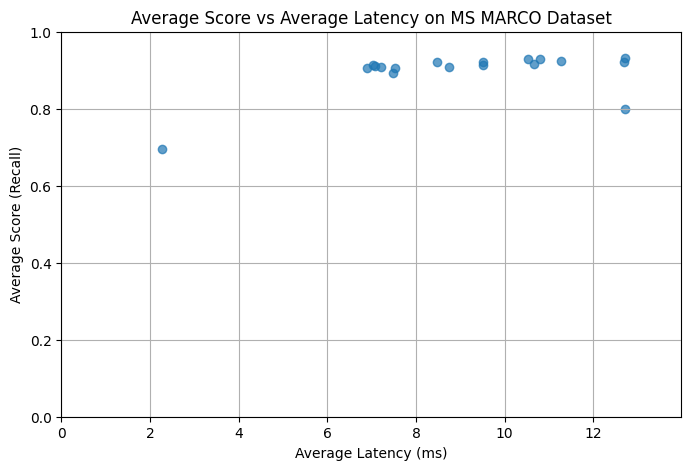

In [23]:
# Plot an avg_score vs avg_latency scatter plot
plt.figure(figsize=(8, 5))

x_vals = [p[0] for p in all_points]
y_vals = [p[1] for p in all_points]
plt.scatter(x_vals, y_vals, alpha=0.7)

plt.xlabel('Average Latency (ms)')
plt.ylabel('Average Score (Recall)')
plt.title('Average Score vs Average Latency on MS MARCO Dataset')
plt.ylim(0, 1)
plt.xlim(0, max([p[0] for p in all_points]) * 1.1)
plt.grid(True)
# plt.legend()
plt.savefig(
    os.path.join(IMAGES_DIR, f'{DATASET_NAME}_avg_score_vs_avg_latency.png'),
    bbox_inches='tight',
    dpi=300
)
plt.show()